# Импорт библиотек

In [2]:
import sys
import os

sys.path.append(os.path.abspath('lib'))

from filters_features_utils import FeatureSelector, FeatureSelectorCV, get_best_xgboost_features_names
from preprocessing_pipeline import create_combined_pipeline
from test_models import run_models_regressions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

# Считывание данных

In [4]:
df = pd.read_csv('data/processed.csv')
df.shape

(1001, 213)

# Удаление невалидных экземляров

In [6]:
matching_instances = df[df['IC50, mM'] == df['CC50, mM']]
print(len(matching_instances.index))
df.drop(index=matching_instances.index, inplace=True)
df.shape

135


(866, 213)

# Очистка таргета от выбросов

(849, 213)


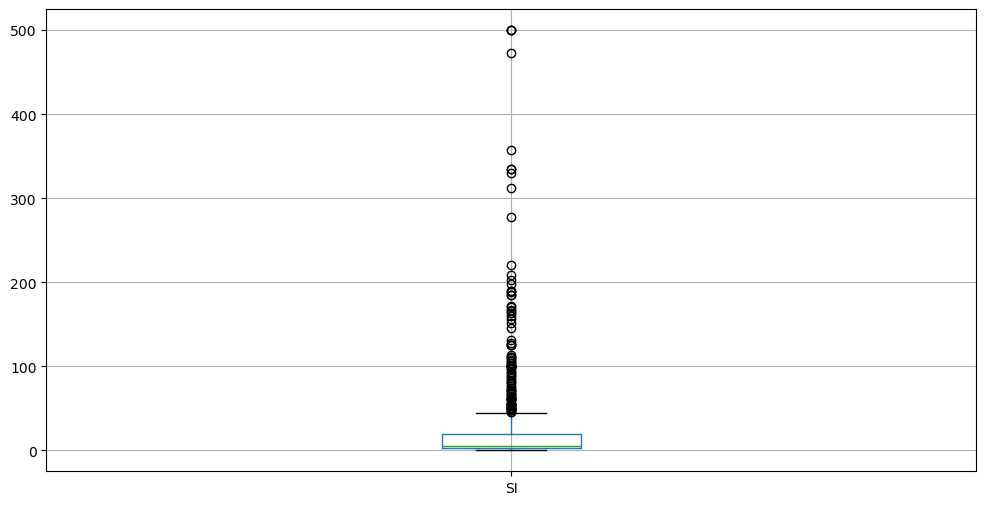

In [8]:
df = df[df['SI'] < 500]
print(df.shape)
df.boxplot(column=['SI'], figsize=(12, 6))
plt.show()

# Подготовка данных для эксперемента

In [10]:
combined_pipeline = create_combined_pipeline()
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y1 = df['IC50, mM']
y2 = df['CC50, mM']
y3 = df['SI']
X_transformed = combined_pipeline.fit_transform(X)
df = pd.concat([X_transformed, y1, y2, y3], axis=1)

In [11]:
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = df['SI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (679, 98), (679,)
Test dataset size: (170, 98), (170,)


# Эксперемент с моделями

In [13]:
run_models_regressions(X_train, X_test, y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,LightGBM,23.04,0.37
4,CatBoost,22.52,0.36
0,Random Forest,22.94,0.34
6,Krr,23.23,0.34
5,HistGradientBoosting,24.34,0.31
1,XGBoost,24.61,0.14
2,Gradient Boosting,24.58,0.09


# Фильтрация признаков

In [15]:
xgboost_features = get_best_xgboost_features_names(X_train, y_train, 100)

In [16]:
featureSelectorCV = FeatureSelectorCV()
featureSelectorCV.fit(X_train, y_train)

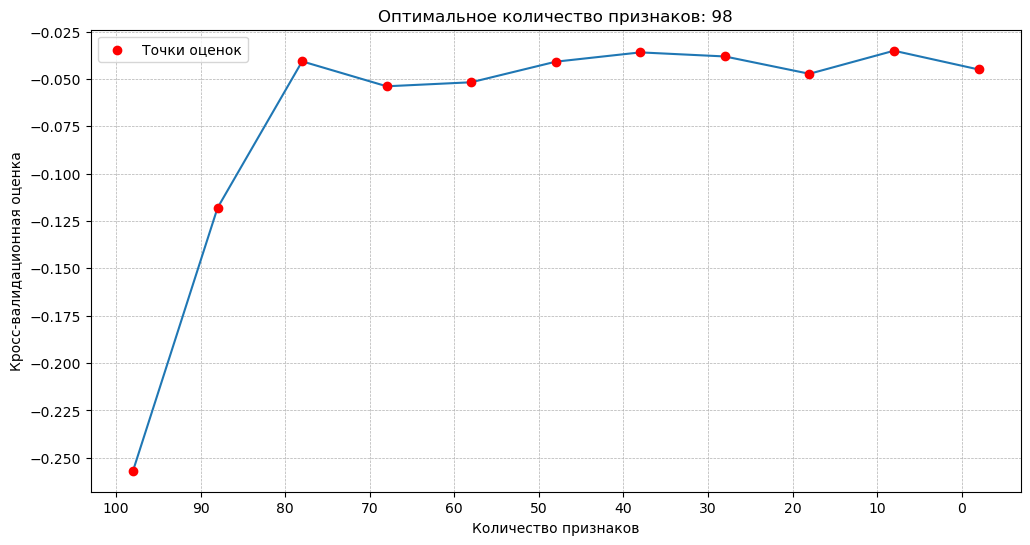

In [17]:
featureSelectorCV.plot_result()

In [18]:
model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_seed=42, verbose=0)
featureSelector = FeatureSelector(model=model, start_index=5, step=5)

In [19]:
featureSelector.calculate_k_best(X_train, X_test, y_train, y_test)

K-Best Progress: 100%|██████████| 19/19 [00:05<00:00,  3.65it/s]


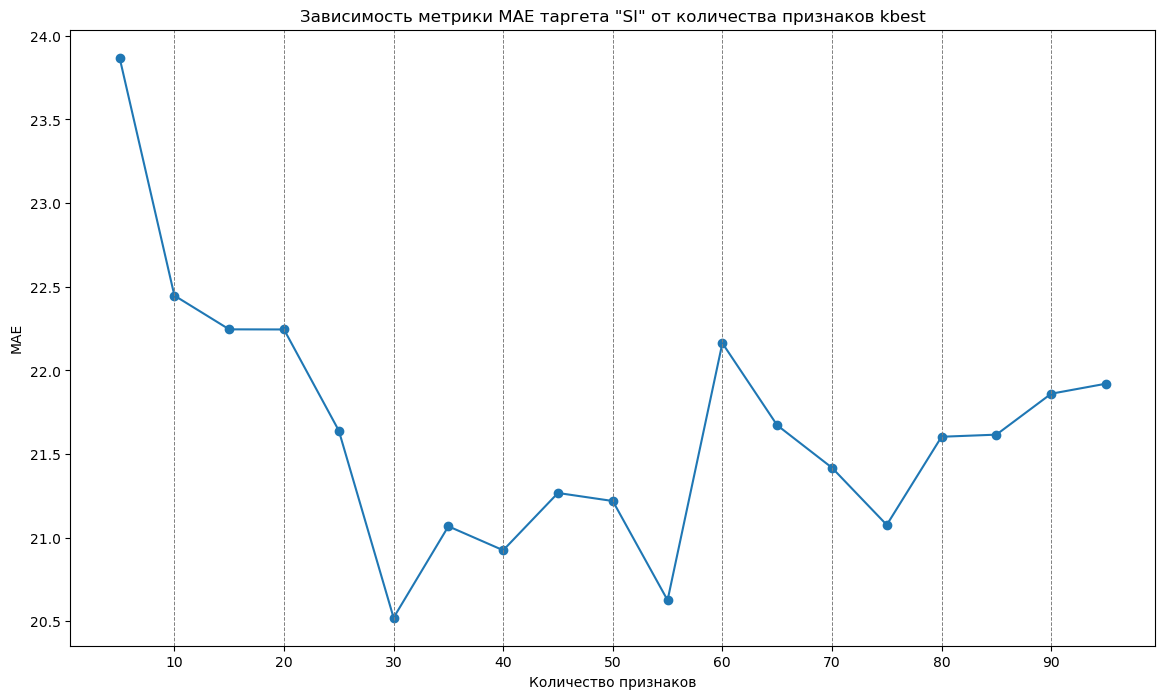

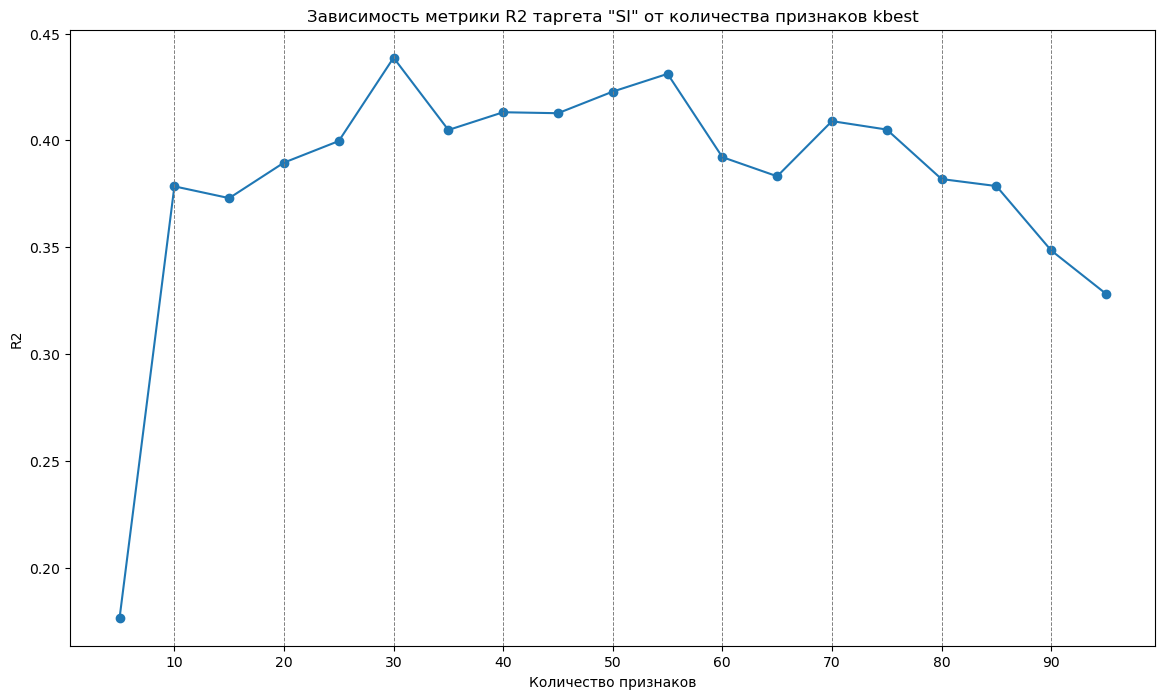

In [20]:
featureSelector.draw_selection(featureSelector.kbest_mae_scores, 'MAE', 'SI', 'kbest')
featureSelector.draw_selection(featureSelector.kbest_r2_scores, 'R2', 'SI', 'kbest')

In [21]:
featureSelector.calculate_rfe(X_train, X_test, y_train, y_test)

RFE Progress: 100%|██████████| 19/19 [01:26<00:00,  4.57s/it]


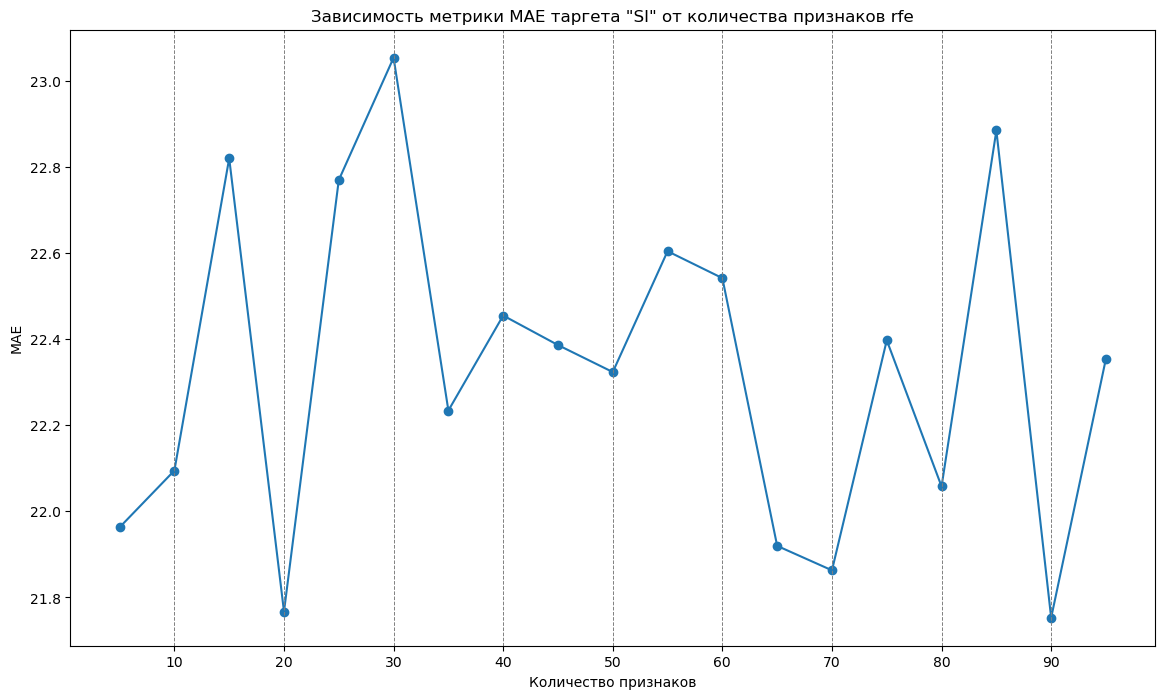

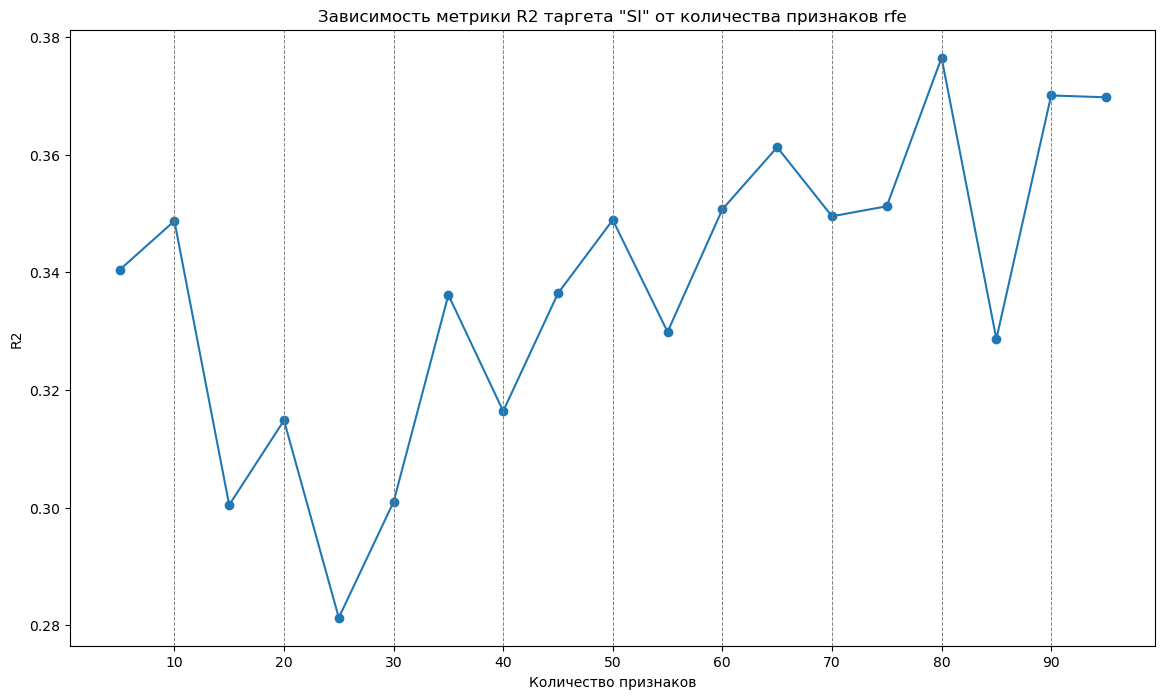

In [22]:
featureSelector.draw_selection(featureSelector.rfe_mae_scores, 'MAE', 'SI', 'rfe')
featureSelector.draw_selection(featureSelector.rfe_r2_scores, 'R2', 'SI', 'rfe')

In [23]:
featureSelector.print_kbest_result()

mae: 20.521825049664542
r2: 0.43866266681445
Index(['NumRotatableBonds', 'fr_Al_COO', 'fr_Al_OH_noTert', 'fr_C_O',
       'fr_Imine', 'fr_NH1', 'fr_NH2', 'fr_Ndealkylation2', 'fr_alkyl_halide',
       'fr_allylic_oxid', 'fr_aryl_methyl', 'fr_benzene', 'fr_bicyclic',
       'fr_ester', 'fr_ether', 'fr_halogen', 'fr_ketone',
       'fr_para_hydroxylation', 'fr_quatN', 'fr_sulfonamd', 'fr_unbrch_alkane',
       'VSA_EState_median', 'VSA_EState_variation', 'PEOE_VSA_variation',
       'SlogP_VSA_variation', 'Chi_variation', 'BCUT2D_variation',
       'Saturation1', 'Flexibility', 'HeavyAtomFraction'],
      dtype='object')


In [24]:
featureSelector.print_rfe_result()

mae: 22.05761124484541
r2: 0.37649071252754784
Index(['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed',
       'SPS', 'MaxPartialCharge', 'HallKierAlpha', 'TPSA', 'NHOHCount',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumAromaticHeterocycles', 'NumAromaticRings', 'NumRotatableBonds',
       'MolLogP', 'fr_Al_COO', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN',
       'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_C_O', 'fr_C_S', 'fr_Imine',
       'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_Ndealkylation1', 'fr_aldehyde',
       'fr_alkyl_carbamate', 'fr_alkyl_halide', 'fr_allylic_oxid', 'fr_amide',
       'fr_aniline', 'fr_aryl_methyl', 'fr_azo', 'fr_benzene', 'fr_bicyclic',
       'fr_epoxide', 'fr_nitrile', 'fr_nitro', 'fr_nitro_arom', 'fr_oxazole',
       'fr_oxime', 'fr_para_hydroxylation', 'fr_piperdine', 'fr_piperzine',
       'fr_priamide', 'fr_pyridine', 'fr_quatN', 'fr_sulfonamd', 'fr_sulfone',
       'fr_term_acetylene', 'fr_thiazole', 'fr_thiophene', 'fr

In [25]:
common_selected_features, combined_selected_features = featureSelector.get_selected_features()

# Эксперемент с моделями

In [27]:
run_models_regressions(X_train, X_test, y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,LightGBM,23.04,0.37
4,CatBoost,22.52,0.36
0,Random Forest,22.94,0.34
6,Krr,23.23,0.34
5,HistGradientBoosting,24.34,0.31
1,XGBoost,24.61,0.14
2,Gradient Boosting,24.58,0.09


In [28]:
run_models_regressions(X_train[xgboost_features], X_test[xgboost_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,LightGBM,23.04,0.37
4,CatBoost,22.12,0.36
0,Random Forest,22.90,0.35
6,Krr,23.23,0.34
5,HistGradientBoosting,24.34,0.31
1,XGBoost,25.20,0.10
2,Gradient Boosting,24.82,0.09


In [29]:
run_models_regressions(X_train[featureSelectorCV.best_features_names], X_test[featureSelectorCV.best_features_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,LightGBM,23.04,0.37
0,Random Forest,22.65,0.35
6,Krr,23.23,0.34
4,CatBoost,22.29,0.33
5,HistGradientBoosting,24.34,0.31
1,XGBoost,24.61,0.14
2,Gradient Boosting,25.18,0.07


In [30]:
run_models_regressions(X_train[featureSelector.kbest_best_feature_names], X_test[featureSelector.kbest_best_feature_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
6,CatBoost,20.52,0.44
5,LightGBM,22.71,0.41
8,Krr,22.15,0.36
2,Random Forest,23.02,0.35
7,HistGradientBoosting,23.58,0.35
0,Linear Regression,25.38,0.18
4,Gradient Boosting,23.72,0.11
1,KNeighbors,24.89,0.04
3,XGBoost,25.35,0.01


In [31]:
run_models_regressions(X_train[featureSelector.rfe_best_feature_names], X_test[featureSelector.rfe_best_feature_names], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
5,CatBoost,22.06,0.38
7,Krr,22.41,0.38
4,LightGBM,23.24,0.36
1,Random Forest,22.81,0.34
6,HistGradientBoosting,24.34,0.31
2,XGBoost,24.48,0.15
3,Gradient Boosting,24.37,0.08
0,KNeighbors,25.17,0.01


In [32]:
run_models_regressions(X_train[common_selected_features], X_test[common_selected_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
5,CatBoost,21.62,0.40
4,LightGBM,23.12,0.39
8,Krr,21.92,0.35
2,Random Forest,23.29,0.34
6,HistGradientBoosting,23.56,0.34
0,Linear Regression,25.63,0.17
3,Gradient Boosting,23.04,0.15
7,AdaBoost,27.78,0.03
1,KNeighbors,25.20,0.01


In [33]:
run_models_regressions(X_train[combined_selected_features], X_test[combined_selected_features], y_train, y_test)

,Model,Mean Absolute Error,R2 Score
3,LightGBM,23.04,0.37
6,Krr,22.86,0.34
0,Random Forest,23.23,0.33
4,CatBoost,22.39,0.33
5,HistGradientBoosting,24.34,0.31
1,XGBoost,24.65,0.11
2,Gradient Boosting,24.33,0.10


# Подбор гиперпараметров

In [37]:
model = CatBoostRegressor(verbose=0, random_seed=42)
param_dist = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'bagging_temperature': [0, 1, 2]
}

best_catboost = GridSearchCV(
    estimator=model,
    param_grid=param_dist,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
best_catboost.fit(X_train[common_selected_features], y_train)

print("Лучшие гиперпараметры:", best_catboost.best_params_)

y_pred = best_catboost.predict(X_test[common_selected_features])

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R2 Score: {r2:.2f}')

Лучшие гиперпараметры: {'bagging_temperature': 0, 'depth': 8, 'iterations': 300, 'l2_leaf_reg': 3, 'learning_rate': 0.01}
Mean Absolute Error: 21.20
R2 Score: 0.44


In [41]:
best_model = CatBoostRegressor(
    bagging_temperature=0,
    depth=8,
    iterations=300,
    l2_leaf_reg=3,
    learning_rate=0.01,
    verbose=0,
    random_state=42,
)

best_model.fit(X_train[common_selected_features], y_train)
y_pred = best_model.predict(X_test[common_selected_features])

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.3f}')
print(f'R2 Score: {r2:.3f}')

Mean Absolute Error: 21.199
R2 Score: 0.437


In [45]:
print(common_selected_features)

Index(['NumRotatableBonds', 'fr_Al_COO', 'fr_Al_OH_noTert', 'fr_C_O',
       'fr_Imine', 'fr_NH1', 'fr_NH2', 'fr_alkyl_halide', 'fr_allylic_oxid',
       'fr_aryl_methyl', 'fr_benzene', 'fr_bicyclic', 'fr_para_hydroxylation',
       'fr_quatN', 'fr_sulfonamd', 'fr_unbrch_alkane', 'VSA_EState_median',
       'VSA_EState_variation', 'PEOE_VSA_variation', 'SlogP_VSA_variation',
       'Chi_variation', 'BCUT2D_variation', 'Saturation1', 'Flexibility',
       'HeavyAtomFraction'],
      dtype='object')
